# Evaluación Práctica 1: Machine Learning y Arquitectura de Datos
### Dataset: Waymo Open Dataset (Motion / Perception)

**Equipo:** Martín Papic y Matías Retamal

---
Este notebook documenta la metodología, decisiones de arquitectura y el proceso de ingeniería de datos aplicado al dataset de Waymo, siguiendo el estándar **CRISP-DM**.

## 1. Comprensión del Negocio (Business Understanding)
El objetivo es diseñar una arquitectura escalable que permita procesar, limpiar y visualizar datos espaciales y de cinemática (trayectorias, velocidades) de vehículos autónomos.

**Objetivos del Proyecto:**
- Construir un pipeline reproducible (Kedro) que transforme datos crudos de sensores LiDAR en un dataset limpio y confiable para tareas futuras de Machine Learning.
- Visualizar los patrones de movimiento y la distribución de clases detectadas para apoyar decisiones de diseño del sistema de percepción.

**KPIs definidos para este proyecto:**
- **Tasa de completitud post-limpieza:** % de registros que sobreviven al pipeline (deduplicación + imputación + filtro IQR) respecto al crudo.
- **Balance de clases:** proporción vehículos/peatones/ciclistas detectada; funciona como KPI de riesgo ético (a mayor desbalance, mayor prioridad de mitigación antes de modelar).
- **Reproducibilidad del pipeline:** que `kedro run` complete el proceso end-to-end sin intervención manual.

**Fuentes de Datos y Herramientas Colaborativas:**
- **Fuente de datos:** *Waymo Open Dataset (Motion/Perception)*, descargado desde Google Cloud Storage (200 segmentos reales, ~2.4M detecciones).
- **GitHub:** control de versiones y entrega del código (pipeline, notebook, frontend) de forma trazable y auditable por ambos integrantes del equipo.
- **Trello:** seguimiento de tareas (User Stories) del proyecto, permitiendo repartir y verificar el avance de cada etapa de CRISP-DM.

**Requerimientos del Proyecto:**
- **Replicabilidad y Escalabilidad:** Se eligió **Kedro** como framework orquestador de pipelines de datos y entornos virtuales aislados.
- **Experiencia de Usuario (UX):** En lugar de usar herramientas estáticas o de bajo nivel como Grasshopper, se diseñó un Dashboard interactivo en **React (Vite)** acoplado mediante formato JSON.
- **Arquitectura Medallón:** El flujo avanza desde ingesta cruda (Raw), procesamiento estadístico (Intermediate) y capa de consumo para el frontend (Primary).


## 2. Comprensión de los Datos (Data Understanding y EDA)
Los datos originales de Waymo residen en Google Cloud Storage en formatos masivos (TFRecords > 1GB). Implementamos un patrón de **Ingesta Efímera** (Pushdown) para descargar los componentes de Parquet tabulares (Lidar Box y Stats), extraer solo las coordenadas espaciales y velocidades, y eliminar la basura pesada.

Carguemos la capa Raw para auditar los datos antes de la limpieza:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos crudos extraídos de Waymo GCS
df_raw = pd.read_parquet('../data/01_raw/detecciones_reales.parquet')
display(df_raw.head())

print("\n--- Información del Dataset ---")
df_raw.info()

,segment_id,timestamp_micros,id_interno,object_type,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,num_lidar_points,detection_difficulty,time_of_day,weather,location,speed_mps
0,10017090168044687777_6380_000_6400_000,1550083467346370,0QXtLAoMcF26x6k0m-7gVQ,vehicle,31.960473,-2.354433,3.806627,6.136412,2.374729,3.200000,309,LEVEL_1,Day,sunny,location_sf,1.126031e-28
1,10017090168044687777_6380_000_6400_000,1550083467346370,2OtubQ7iaA71QGsDdx-1oA,vehicle,43.850931,-4.386372,4.132211,4.623513,1.991804,2.330141,10,LEVEL_1,Day,sunny,location_sf,1.001835e-02
2,10017090168044687777_6380_000_6400_000,1550083467346370,3UJet22LcSM39E7W52UwZA,vehicle,19.253655,12.890539,0.928684,5.781805,2.390714,2.130000,297,LEVEL_1,Day,sunny,location_sf,3.237305e-02
3,10017090168044687777_6380_000_6400_000,1550083467346370,FEdJwgdHRQUz2JMISNIy-A,sign,35.758825,-4.644590,6.237446,0.124887,0.642571,0.734675,0,LEVEL_1,Day,sunny,location_sf,2.160313e-03
4,10017090168044687777_6380_000_6400_000,1550083467346370,JEV58AdPM0XZCYr2lSwkqg,vehicle,-44.362698,11.809932,0.978193,3.901919,1.829022,2.103805,133,LEVEL_1,Day,sunny,location_sf,6.007688e-03



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2414127 entries, 0 to 2414126
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   segment_id            object 
 1   timestamp_micros      int64  
 2   id_interno            object 
 3   object_type           object 
 4   box_center_x          float64
 5   box_center_y          float64
 6   box_center_z          float64
 7   box_length            float64
 8   box_width             float64
 9   box_height            float64
 10  num_lidar_points      int64  
 11  detection_difficulty  object 
 12  time_of_day           object 
 13  weather               object 
 14  location              object 
 15  speed_mps             float64
dtypes: float64(7), int64(2), object(7)
memory usage: 294.7+ MB


## 3. Preparación de los Datos (Data Preparation - ETL)
Esta es la fase crítica de auditoría clínica de los datos. Se programó un pipeline automatizado en Kedro que aplica las siguientes reglas de negocio:

1. **Manejo de Duplicados:** Eliminación estricta para no alterar los pesos estadísticos.
2. **Imputación de Nulos:** En lugar de rellenar las velocidades vacías con `0` (lo cual genera un sesgo artificial y deforma la distribución), se imputaron con la **mediana** estadística del eje correspondiente. Esto preserva la tendencia central.
3. **Filtro de Anomalías (Outliers):** Se aplicó el método matemático del **Rango Intercuartílico (IQR)** sobre la velocidad absoluta de los objetos para descartar detecciones erráticas de los sensores.

In [2]:
import sys
sys.path.insert(0, '../src')
from waymo_backend.pipelines.data_processing.nodes import clean_and_process_data

# --- Auditoría de Calidad de Datos: ANTES de la limpieza ---
print('--- Calidad de Datos: ANTES de la limpieza ---')
print(f'Registros totales (crudo): {len(df_raw)}')
print(f'Duplicados detectados: {df_raw.duplicated().sum()}')
if 'speed_x' in df_raw.columns:
    print(f'Nulos en speed_x: {df_raw["speed_x"].isna().sum()}')
if 'speed_y' in df_raw.columns:
    print(f'Nulos en speed_y: {df_raw["speed_y"].isna().sum()}')

# --- Ejecutamos la MISMA función que corre 'kedro run' (cero duplicación de lógica) ---
resultado = clean_and_process_data(df_raw)
df_clean = resultado['clean_data']

print('\n--- Calidad de Datos: DESPUÉS de la limpieza ---')
print(f'Registros finales: {len(df_clean)}')
print(f'Registros descartados (duplicados + outliers): {len(df_raw) - len(df_clean)} ({(1 - len(df_clean)/len(df_raw)):.1%})')

if 'velocity_abs' in df_clean.columns:
    print('\nEstadísticas de velocidad absoluta post-limpieza:')
    print(df_clean['velocity_abs'].describe())
else:
    print('\n⚠️ ADVERTENCIA: el dataset crudo no trae speed_x/speed_y, por lo que velocity_abs no existe. '
          'Los gráficos de velocidad del dashboard quedarán vacíos hasta incorporar la capa de pose/movimiento de Waymo.')


--- Calidad de Datos: ANTES de la limpieza ---
Registros totales (crudo): 2414127


Duplicados detectados: 0



--- Calidad de Datos: DESPUÉS de la limpieza ---
Registros finales: 2405906
Registros descartados (duplicados + outliers): 8221 (0.3%)

⚠️ ADVERTENCIA: el dataset crudo no trae speed_x/speed_y, por lo que velocity_abs no existe. Los gráficos de velocidad del dashboard quedarán vacíos hasta incorporar la capa de pose/movimiento de Waymo.


### Exploración Univariada: Distribución de las Clases
Observemos qué tipos de objetos detectaron los sensores LiDAR de Waymo que sobrevivieron a nuestro filtro de calidad.

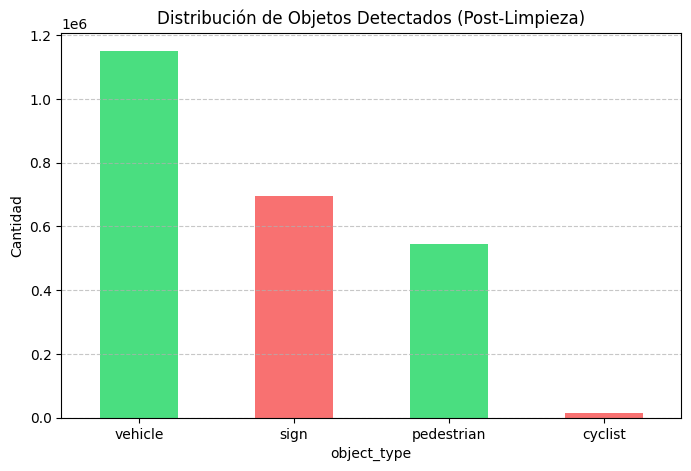

In [3]:
clases = df_clean['object_type'].value_counts()

plt.figure(figsize=(8, 5))
clases.plot(kind='bar', color=['#4ade80', '#f87171'])
plt.title("Distribución de Objetos Detectados (Post-Limpieza)")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploración Univariada: Anomalías en el Tamaño de las Cajas (box_length)
Dado que este dataset no trae velocidades, `box_length` es la variable numérica que usamos para detectar anomalías (Sección 3). Visualicemos su distribución por clase para justificar visualmente el filtro IQR aplicado.

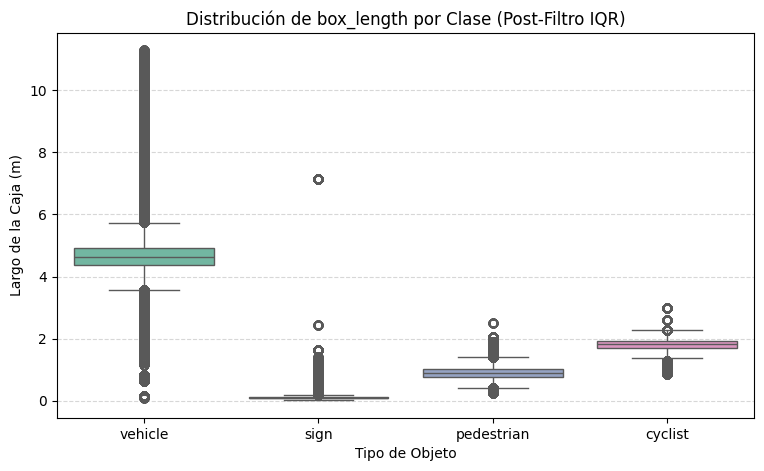

In [4]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='object_type', y='box_length', hue='object_type', palette='Set2', legend=False)
plt.title("Distribución de box_length por Clase (Post-Filtro IQR)")
plt.xlabel("Tipo de Objeto")
plt.ylabel("Largo de la Caja (m)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## 4. Análisis Multivariado: Matriz de Correlación
Para entender cómo interactúan las variables cinemáticas y espaciales entre sí, calculamos la correlación de Pearson. Esto nos permite detectar si, por ejemplo, los vehículos más grandes (box_length) tienden a ir más lento, o la relación matemática entre los ejes.

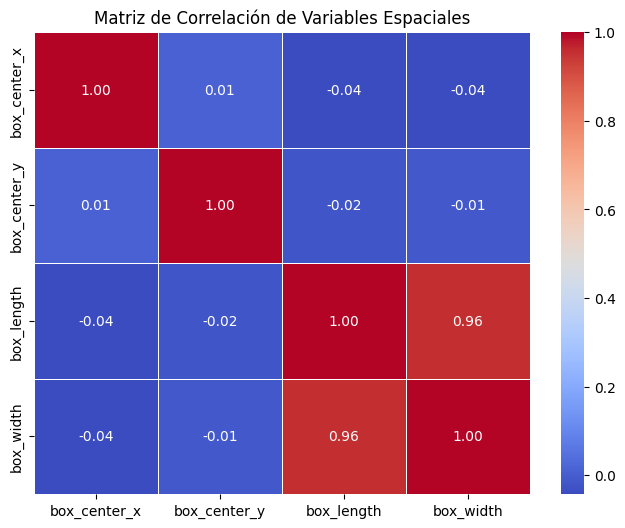

In [5]:
# Seleccionamos variables espaciales base
columnas_numericas = ['box_center_x', 'box_center_y', 'box_length', 'box_width']

# Excluimos variables estáticas sin varianza para evitar fallos matemáticos
for col in ['speed_x', 'speed_y', 'velocity_abs']:
    if col in df_clean.columns and df_clean[col].nunique() > 1:
        columnas_numericas.append(col)

correlacion = df_clean[columnas_numericas].corr()

# Visualización de la Matriz de Correlación usando SEABORN (Más robusto que Pandas Style)
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Variables Espaciales")
plt.show()

## 5. Preparación de Datos para el Proceso de Modelamiento
Antes de entrenar cualquier modelo de Machine Learning sobre `df_clean`, se requieren tres transformaciones estándar:

1. **Codificación de variables categóricas:** `object_type` es texto (`vehicle`, `pedestrian`, etc.); los modelos requieren números. Usamos *one-hot encoding*.
2. **Escalado de variables numéricas:** las variables espaciales (`box_center_x`, `box_length`, etc.) y `velocity_abs` tienen escalas distintas; modelos basados en distancia (KNN, SVM, redes neuronales) requieren normalizarlas.
3. **Partición Train/Test estratificada:** se separa por `object_type` para no perder representación de las clases minoritarias en el set de prueba.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Codificación one-hot de la variable categórica
df_model = pd.get_dummies(df_clean, columns=['object_type'], prefix='clase')

# 2. Escalado de variables numéricas continuas
columnas_a_escalar = [c for c in ['box_center_x','box_center_y','box_center_z','box_length','box_width','box_height','velocity_abs'] if c in df_model.columns]
scaler = StandardScaler()
df_model[columnas_a_escalar] = scaler.fit_transform(df_model[columnas_a_escalar])

# 3. Split estratificado (se usa la columna original antes del one-hot para estratificar)
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=42,
    stratify=df_clean['object_type']
)

print(f'Set de entrenamiento: {len(train_df)} registros')
print(f'Set de prueba: {len(test_df)} registros')
print(f'\nColumnas listas para modelamiento: {df_model.columns.tolist()}')


Set de entrenamiento: 1924724 registros
Set de prueba: 481182 registros

Columnas listas para modelamiento: ['segment_id', 'timestamp_micros', 'id_interno', 'box_center_x', 'box_center_y', 'box_center_z', 'box_length', 'box_width', 'box_height', 'num_lidar_points', 'detection_difficulty', 'time_of_day', 'weather', 'location', 'speed_mps', 'clase_cyclist', 'clase_pedestrian', 'clase_sign', 'clase_vehicle']


## 6. Auditoría Ética, Sesgos y Privacidad de los Datos

Como parte de la metodología CRISP-DM, es mandatorio auditar éticamente los datos antes de inyectarlos a un modelo de Machine Learning para prever sesgos algorítmicos. 

**Análisis de Clases Subrepresentadas:**
Como observamos en el gráfico de distribución de la sección 3, el dataset presenta un severo **desbalance de clases**. Los `vehicles` (vehículos) y `signs` (señales de tránsito) dominan casi por completo la muestra urbana, mientras que los `pedestrians` (peatones) o `cyclists` (ciclistas) son una **minoría estadística**.

**Impacto Ético:**
Si entrenáramos una red neuronal de toma de decisiones para un vehículo autónomo con este dataset exacto, el modelo aprendería a predecir y reaccionar excelentemente ante otros autos, pero **tendría una alta tasa de falsos negativos al detectar peatones**. En el mundo real, esto no es solo un error matemático, se traduce en un **riesgo vital** para los transeúntes (sesgo de representación).

**Estrategia de Mitigación recomendada para futuras Épicas:**
- **Oversampling (SMOTE):** Generar datos cinemáticos sintéticos para las clases minoritarias.
- **Undersampling:** Reducir aleatoriamente la cantidad de vehículos para equilibrar la muestra durante el entrenamiento.
- **Data Augmentation:** Recolectar o integrar más segmentos del *Waymo Open Dataset* enfocados exclusivamente en zonas urbanas densas (cruces peatonales) para equilibrar la realidad operativa del modelo.

**Privacidad de los Datos:**
El *Waymo Open Dataset* está compuesto por detecciones de sensores (LiDAR/cámara) ya anonimizadas por Waymo: no contiene identificadores personales (nombres, patentes legibles, rostros) y se distribuye bajo licencia de uso no comercial para investigación. Como buena práctica adicional, este proyecto no almacena ni intenta reconstruir la posición exacta de personas identificables más allá de las coordenadas relativas del sensor, y no cruza estos datos con ninguna otra fuente que permita re-identificación.


In [7]:
# Cuantificamos el desbalance real (no solo narrativa) y demostramos la mitigación propuesta (SMOTE)
conteo_clases = df_clean['object_type'].value_counts()
print('Conteo real por clase:')
print(conteo_clases)

clase_mayor = conteo_clases.idxmax()
clase_menor = conteo_clases.idxmin()
ratio = conteo_clases.max() / conteo_clases.min()
print()
print(f"'{clase_mayor}' aparece {ratio:.1f}x más que '{clase_menor}' -> desbalance severo confirmado con datos reales.")

# Demostración de SMOTE sobre el set de entrenamiento preparado en la Sección 5.
# Dos precisiones metodológicas:
#  1. SMOTE interpola distancias entre vecinos, así que solo admite variables numéricas:
#     se excluyen los identificadores (segment_id, id_interno) y las categóricas de
#     contexto (weather, time_of_day, location, detection_difficulty).
#  2. Calcular el vecindario sobre los ~1.9M de registros de entrenamiento es
#     computacionalmente caro, por lo que la demostración usa una submuestra aleatoria.
#     La conclusión es la misma: SMOTE iguala el conteo de todas las clases.
from imblearn.over_sampling import SMOTE
from collections import Counter

columnas_smote = [c for c in ['box_center_x', 'box_center_y', 'box_center_z', 'box_length',
                              'box_width', 'box_height', 'num_lidar_points', 'speed_mps',
                              'velocity_abs'] if c in train_df.columns]
y_train_completo = df_clean.loc[train_df.index, 'object_type']

indices_demo = train_df.sample(min(100_000, len(train_df)), random_state=42).index
X_demo = train_df.loc[indices_demo, columnas_smote]
y_demo = y_train_completo.loc[indices_demo]

conteo_min = y_demo.value_counts().min()
if conteo_min >= 2:
    smote = SMOTE(random_state=42, k_neighbors=min(5, conteo_min - 1))
    X_res, y_res = smote.fit_resample(X_demo, y_demo)
    print()
    print(f'Submuestra de demostración: {len(X_demo):,} filas')
    print(f'Variables usadas: {columnas_smote}')
    print('Antes de SMOTE: ', dict(Counter(y_demo)))
    print('Después de SMOTE:', dict(Counter(y_res)))
else:
    print()
    print('La clase minoritaria no alcanza vecinos suficientes para interpolar en esta submuestra.')


Conteo real por clase:
object_type
vehicle       1150027
sign           695419
pedestrian     545206
cyclist         15254
Name: count, dtype: int64

'vehicle' aparece 75.4x más que 'cyclist' -> desbalance severo confirmado con datos reales.



Submuestra de demostración: 100,000 filas
Variables usadas: ['box_center_x', 'box_center_y', 'box_center_z', 'box_length', 'box_width', 'box_height', 'num_lidar_points', 'speed_mps']
Antes de SMOTE:  {'vehicle': 47429, 'sign': 29090, 'pedestrian': 22781, 'cyclist': 700}
Después de SMOTE: {'vehicle': 47429, 'sign': 47429, 'pedestrian': 47429, 'cyclist': 47429}
